# 타이타닉 생존자 예측

1. 데이터 확인
2. 결측치 처리
3. 인코딩
4. 모델 학습 / 평가
5. 교차 검증
6. 하이퍼파라미터 튜닝
7. 튜닝된 하이퍼파라미터로 재학습

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [24]:
titanic_df = pd.read_csv('data/titanic_train.csv', encoding='utf-8')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
titanic_df.info() # 데이터 구조 확인 (Age, Cabin, Embarked 결측치 존재)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [26]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [27]:
titanic_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [28]:
titanic_df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [29]:
titanic_df['Age'].mean()

np.float64(29.69911764705882)

In [30]:
titanic_df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [31]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('N')
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('N')

In [32]:
titanic_df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [33]:
titanic_df['Cabin'].unique() # Cabin은 범주형이지만 정리 필요

<StringArray>
[          'N',         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [34]:
titanic_df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [35]:
titanic_df['Cabin'].value_counts()

Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F33              3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

In [36]:
titanic_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64

In [37]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]
titanic_df['Cabin'].value_counts()

Cabin
N    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [38]:
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

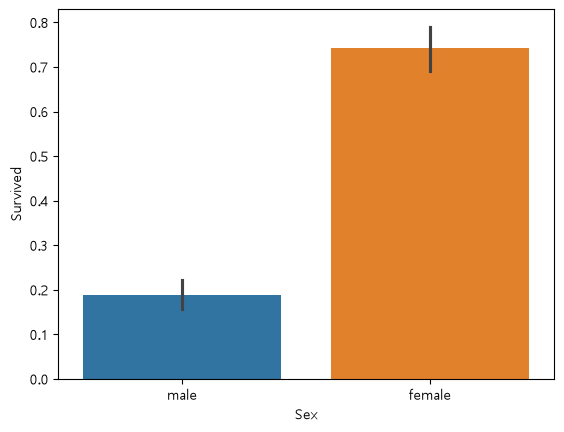

In [39]:
sns.barplot(x='Sex', y='Survived', hue='Sex', data=titanic_df)

<Axes: xlabel='Age_type', ylabel='Survived'>

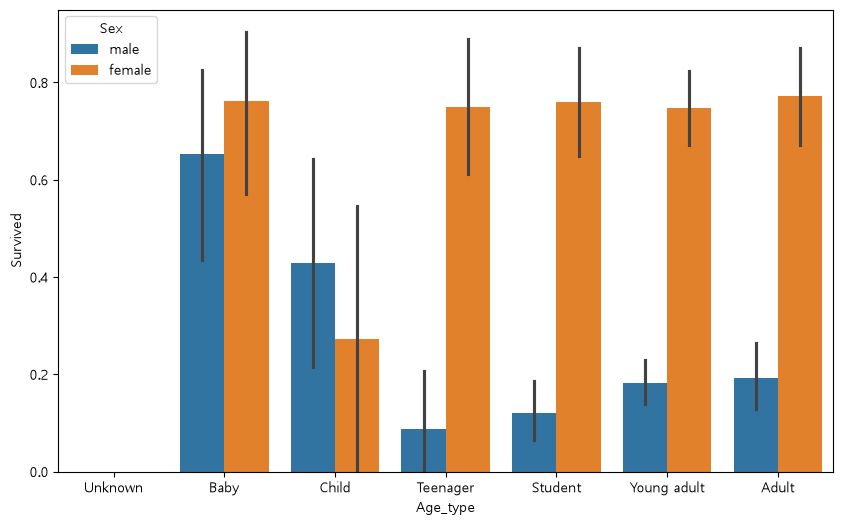

In [40]:
def get_category(age):
    age_type = ''
    if age <= -1: age_type = 'Unknown'
    elif age <= 5: age_type = 'Baby'
    elif age <= 12: age_type = 'Child'
    elif age <= 18: age_type = 'Teenager'
    elif age <= 25: age_type = 'Student'
    elif age <= 35: age_type = 'Young adult'
    elif age <= 60: age_type = 'Adult'
    else: age_type = 'Elderly'

    return age_type

plt.figure(figsize=(10, 6))
group_name = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young adult', 'Adult']

titanic_df['Age_type'] = titanic_df['Age'].apply(lambda x: get_category(x))
sns.barplot(x='Age_type', y='Survived', hue='Sex', data=titanic_df, order=group_name)

나이는 생존여부에 영향을 끼침  
어린 남성도 상대적으로 생존율 높음

In [41]:
titanic_df = titanic_df.drop('Age_type', axis=1)
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,N,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,N,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,N,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,N,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,N,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C,C


In [42]:
from sklearn.preprocessing import LabelEncoder

def encode_features(dataDF):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])
    
    return dataDF

titanic_df = encode_features(titanic_df)
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.0000,7,3
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.0000,1,3
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.4500,7,3
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.0000,2,0


In [43]:
def fillna(df):
    df = df.copy()

    df['Age'] = df['Age'].fillna(titanic_df['Age'].mean())
    df['Cabin'] = df['Cabin'].fillna('N')
    df['Embarked'] = df['Embarked'].fillna('N')

    return df

def drop_features(df):
    df = df.copy()
    df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

    return df

def format_features(df):
    df = df.copy()

    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']

    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    
    return df

def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)

    return df

In [44]:
titanic_df = pd.read_csv('data/titanic_train.csv')

y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

X_titanic_df = transform_features(X_titanic_df)
X_titanic_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,1,22.000000,1,0,7.2500,7,3
1,1,0,38.000000,1,0,71.2833,2,0
2,3,0,26.000000,0,0,7.9250,7,3
3,1,0,35.000000,1,0,53.1000,2,3
4,3,1,35.000000,0,0,8.0500,7,3
...,...,...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000,7,3
887,1,0,19.000000,0,0,30.0000,1,3
888,3,0,29.699118,1,2,23.4500,7,3
889,1,1,26.000000,0,0,30.0000,2,0


In [45]:
# 기본적 전처리 완료, 성능 향상 측면에서 정규화, 표준화 추가 가능
# DecisionTree., RandomForest 계열은 데이터 스케일링 영향 적음
# 만약 Logistic 사용하면 해주는게 더 좋음

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_df,
    y_titanic_df,
    test_size=0.2,
    random_state=11
)


print(len(X_train), len(X_test), len(y_train), len(y_test))

712 179 712 179


In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver='liblinear')

dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
print(f'DT Acc: {accuracy_score(y_test, dt_pred):.4f}')

rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
print(f'RF Acc: {accuracy_score(y_test, rf_pred):.4f}')

lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
print(f'LR Acc: {accuracy_score(y_test, lr_pred):.4f}')

DT Acc: 0.7877
RF Acc: 0.8547
LR Acc: 0.8659


In [50]:
from sklearn.model_selection import KFold

def exec_kfold(clf, folds=5):
    kfold = KFold(n_splits=folds)
    scores = []

    for iter_count, (train_index, test_index) in enumerate(kfold.split(X_titanic_df)):
        X_train, X_test = X_titanic_df.values[train_index], X_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]

        clf.fit(X_train, y_train)
        predictions = clf.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        scores.append(accuracy)

        print(f'Cross Validation {iter_count+1} Acc: {accuracy:.4f}')

    mean_scores = np.mean(scores)
    print(f"Mean Acc: {mean_scores:.4f}")

exec_kfold(dt_clf, folds=5)

Cross Validation 1 Acc: 0.7542
Cross Validation 2 Acc: 0.7809
Cross Validation 3 Acc: 0.7865
Cross Validation 4 Acc: 0.7697
Cross Validation 5 Acc: 0.8202
Mean Acc: 0.7823


In [51]:
exec_kfold(rf_clf, folds=5)

Cross Validation 1 Acc: 0.7933
Cross Validation 2 Acc: 0.8090
Cross Validation 3 Acc: 0.8371
Cross Validation 4 Acc: 0.7753
Cross Validation 5 Acc: 0.8596
Mean Acc: 0.8148


In [52]:
exec_kfold(lr_clf, folds=5)

Cross Validation 1 Acc: 0.7933
Cross Validation 2 Acc: 0.7921
Cross Validation 3 Acc: 0.7753
Cross Validation 4 Acc: 0.7472
Cross Validation 5 Acc: 0.8427
Mean Acc: 0.7901


In [56]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(dt_clf, X_titanic_df, y_titanic_df, cv=5)
for iter_count, accuracy in enumerate(scores):
    print(f'CV {iter_count+1} Acc: {accuracy:.4f}')
print(f'Mean CV Acc: {scores.mean():.4f}')

CV 1 Acc: 0.7430
CV 2 Acc: 0.7753
CV 3 Acc: 0.7921
CV 4 Acc: 0.7865
CV 5 Acc: 0.8427
Mean CV Acc: 0.7879


11. 하이퍼파라미터 최적화 도구 GridSearchCV
- 미리 정해둔 파라미터 조합 모두 시도해 가장 좋은 조합 찾기
- 탐색 범위 적을 때 사용 용이, 조합 많으면 실행시간 급상승

In [61]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'max_depth': [2, 3, 5, 10, 50, 100],
    'min_samples_split': [2, 3, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 8, 20]
}

grid_dclf = GridSearchCV(dt_clf, parameters, scoring='accuracy', cv=5)
grid_dclf.fit(X_train, y_train)

print(f'GridSearchCV의 최적 하이퍼파라미터: {grid_dclf.best_params_}')
print(f'GridSearchCV의 최적 정확도: {grid_dclf.best_score_}')

best_dclf = grid_dclf.best_estimator_

GridSearchCV의 최적 하이퍼파라미터: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
GridSearchCV의 최적 정확도: 0.8005712597261894


In [62]:
dpredictions = best_dclf.predict(X_test)
accuracy = accuracy_score(dpredictions, y_test)
print(f'테스트셋에서의 정확도: {accuracy:.4f}')

테스트셋에서의 정확도: 0.8715


12. Optuna 하이퍼파라미터 튜닝
- 모든 조합 반복 않고, 이전 trial 결과 참고해 더 좋은 조합 찾음
- Optuna에서 나온 cv 점수는 학습데이터에서 나온 것, 차후 테스트 데이터로 재검증 필요

In [66]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 11
    }

    model = DecisionTreeClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    return scores.mean()

sampler = TPESampler(seed=11)
study = optuna.create_study(direction='maximize', sampler=sampler)

study.optimize(objective, n_trials=200)

print(f'Optuna 최적 하이퍼파라미터: {study.best_params}')
print(f'Optuna 최적 정확도: {study.best_value:.4f}')

Optuna 최적 하이퍼파라미터: {'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 1, 'criterion': 'entropy'}
Optuna 최적 정확도: 0.8061


In [67]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

best_params = study.best_params.copy()
final_optuna_model = DecisionTreeClassifier(**best_params, random_state=11)
final_optuna_model.fit(X_train, y_train)
final_pred = final_optuna_model.predict(X_test)

final_accuracy = accuracy_score(y_test, final_pred)

print(f"최적의 하이퍼파라미터: {best_params}")
print(f"최적의 교차검증 정확도: {study.best_value:.4f}")
print(f"최종 테스트 정확도: {final_accuracy:.4f}")

최적의 하이퍼파라미터: {'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 1, 'criterion': 'entropy'}
최적의 교차검증 정확도: 0.8061
최종 테스트 정확도: 0.8324


In [68]:
cm = confusion_matrix(y_test, final_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Pred 0', 'Pred 1']
)

cm_df

,Pred 0,Pred 1
Actual 0,113,5
Actual 1,25,36


In [71]:
print(classification_report(y_test, final_pred, target_names=['사망(0)', '생존(1)']))

              precision    recall  f1-score   support

       사망(0)       0.82      0.96      0.88       118
       생존(1)       0.88      0.59      0.71        61

    accuracy                           0.83       179
   macro avg       0.85      0.77      0.79       179
weighted avg       0.84      0.83      0.82       179



In [72]:
comparison_df = pd.DataFrame({
    'Model': [
        'DecisionTree 기본 모델',
        'RandomForest 기본 모델',
        'LogisticRegression 기본 모델',
        'GridSearchCV DecisionTree',
        'Optuna DecisionTree'
    ],
    'Test Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dpredictions),
        final_accuracy
    ]
})

comparison_df.sort_values('Test Accuracy', ascending=False)

,Model,Test Accuracy
3,GridSearchCV DecisionTree,0.871508
2,LogisticRegression 기본 모델,0.865922
1,RandomForest 기본 모델,0.854749
4,Optuna DecisionTree,0.832402
0,DecisionTree 기본 모델,0.787709


### 고도화
1. DT 외에 RF / LR / Boosting 계열 사용해서 하이퍼파라미터 최적화해서 성능 극대화
2. 여러 방법으로 성능 개선
- LabelEncoding -> 원핫인코딩
- 스케일러 적용
3. 학습 데이터셋은 학습만 사용, 테스트 데이터셋 추가 다운받아 테스트용으로만 사용


In [83]:
def rf_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 11
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    return scores.mean()

sampler = TPESampler(seed=11)
study = optuna.create_study(direction='maximize', sampler=sampler)

study.optimize(rf_objective, n_trials=100)

best_params = study.best_params.copy()
final_optuna_model = RandomForestClassifier(**best_params, random_state=11)
final_optuna_model.fit(X_train, y_train)
final_pred = final_optuna_model.predict(X_test)

final_accuracy = accuracy_score(y_test, final_pred)

print(f"최적의 하이퍼파라미터: {best_params}")
print(f'최적 정확도: {study.best_value:.4f}')
print(f"최적의 교차검증 정확도: {study.best_value:.4f}")
print(f"최종 테스트 정확도: {final_accuracy:.4f}")

최적의 하이퍼파라미터: {'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 7, 'criterion': 'gini'}
최적 정확도: 0.8146
최적의 교차검증 정확도: 0.8146
최종 테스트 정확도: 0.8659


In [ ]:
def lr_objective(trial):
    params = {
        'tol': trial.suggest_float('tol', 0.001, 0.01),
        'max_iter': trial.suggest_int('max_iter', 100, 1000),
        'warm_start': trial.suggest_categorical('warm_start', [True, False]),
        'random_state': 11
    }

    model = LogisticRegression(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    return scores.mean()

sampler = TPESampler(seed=11)
study = optuna.create_study(direction='maximize', sampler=sampler)

study.optimize(lr_objective, n_trials=100)

best_params = study.best_params.copy()
final_optuna_model = LogisticRegression(**best_params, random_state=11)
final_optuna_model.fit(X_train, y_train)
final_pred = final_optuna_model.predict(X_test)

final_accuracy = accuracy_score(y_test, final_pred)

print(f"최적의 하이퍼파라미터: {best_params}")
print(f'최적 정확도: {study.best_value:.4f}')
print(f"최적의 교차검증 정확도: {study.best_value:.4f}")
print(f"최종 테스트 정확도: {final_accuracy:.4f}")

c:\Users\playdata2\ML\ml_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 117 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=117).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\playdata2\ML\ml_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 117 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=117).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

최적의 하이퍼파라미터: {'tol': 0.009476259871090298, 'max_iter': 866, 'warm_start': True}
최적 정확도: 0.7795
최적의 교차검증 정확도: 0.7795
최종 테스트 정확도: 0.8547


In [93]:
from sklearn.preprocessing import OneHotEncoder

def fillna(df):
    df = df.copy()

    df['Age'] = df['Age'].fillna(titanic_df['Age'].mean())
    df['Cabin'] = df['Cabin'].fillna('N')
    df['Embarked'] = df['Embarked'].fillna('N')

    return df

def drop_features(df):
    df = df.copy()
    df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

    return df

def onehot_features(df):
    df = df.copy()

    df['Cabin'] = df['Cabin'].str[:1]

    return pd.get_dummies(
        df,
        columns=['Cabin', 'Sex', 'Embarked'],
        dtype=int
    )

def preprocessing_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = onehot_features(df)

    return df

In [94]:
titanic_df = pd.read_csv('data/titanic_train.csv')

y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

X_titanic_df = preprocessing_features(X_titanic_df)
X_titanic_df

,Pclass,Age,SibSp,Parch,Fare,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_N,Cabin_T,Sex_female,Sex_male,Embarked_C,Embarked_N,Embarked_Q,Embarked_S
0,3,22.000000,1,0,7.2500,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1
1,1,38.000000,1,0,71.2833,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0
2,3,26.000000,0,0,7.9250,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1
3,1,35.000000,1,0,53.1000,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
4,3,35.000000,0,0,8.0500,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,27.000000,0,0,13.0000,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1
887,1,19.000000,0,0,30.0000,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1
888,3,29.699118,1,2,23.4500,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1
889,1,26.000000,0,0,30.0000,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0


In [95]:
def rf_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 11
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    return scores.mean()

sampler = TPESampler(seed=11)
study = optuna.create_study(direction='maximize', sampler=sampler)

study.optimize(rf_objective, n_trials=100)

best_params = study.best_params.copy()
final_optuna_model = RandomForestClassifier(**best_params, random_state=11)
final_optuna_model.fit(X_train, y_train)
final_pred = final_optuna_model.predict(X_test)

final_accuracy = accuracy_score(y_test, final_pred)

print(f"최적의 하이퍼파라미터: {best_params}")
print(f'최적 정확도: {study.best_value:.4f}')
print(f"최적의 교차검증 정확도: {study.best_value:.4f}")
print(f"최종 테스트 정확도: {final_accuracy:.4f}")

최적의 하이퍼파라미터: {'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 7, 'criterion': 'gini'}
최적 정확도: 0.8146
최적의 교차검증 정확도: 0.8146
최종 테스트 정확도: 0.8659
